<a href="https://colab.research.google.com/github/ArielShenhav/data-science-homework2/blob/main/homework2_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Regression Error Analysis

In this section, we analyze regression models and investigate their prediction errors using a Diabetes Dataset.

The dataset contains medical information about female patients, including features such as glucose level, BMI, insulin level, blood pressure, and age.

For the regression task, the target variable is the glucose level.

The goal is to evaluate model performance, examine residual behavior, and identify systematic error patterns.

## Data Loading


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/ArielShenhav/data-science-homework2/main/diabetes.csv"

df = pd.read_csv(url)
print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 1.1 Residual Analysis

For each observation, the residual is defined as:

Residual = y - ŷ

where:
- y is the true value
- ŷ is the predicted value

In this section, we analyze the residuals of the regression model in order to evaluate prediction behavior and detect systematic error patterns.

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Preparing the Regression Task

For the regression analysis, the target variable is the glucose level.

The remaining medical features are used as predictors.

In [85]:
X = df.drop(columns=['Glucose', 'Outcome'])
y = df['Glucose']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

residuals = y_test - y_pred

### Residuals as a Function of Predicted Values

The following plot presents the residuals as a function of the predicted glucose values.

This visualization helps identify:
- Systematic prediction patterns
- Non-linear behavior
- Heteroscedasticity
- Outliers

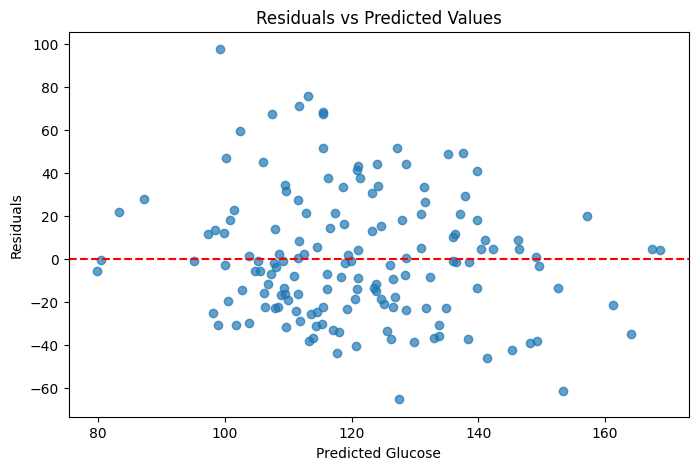

In [86]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Glucose")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

### Distribution of Residuals

The histogram below shows the distribution of the residuals.

A well-behaved regression model is expected to produce residuals approximately centered around zero.

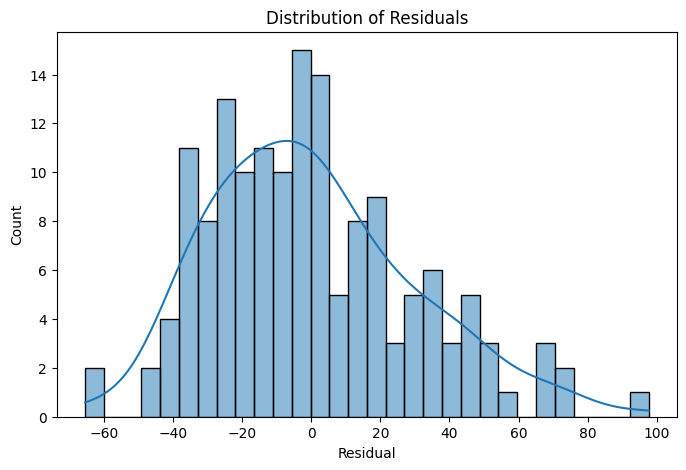

In [87]:
plt.figure(figsize=(8, 5))

sns.histplot(residuals, bins=30, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

### Discussion

The residual analysis shows that most residuals are centered around zero, indicating that the regression model does not exhibit a strong systematic prediction bias.

However, the residual plots also reveal some spread variation and several larger residuals, suggesting that the model struggles in certain regions of the dataset. This may indicate non-linear relationships and mild heteroscedasticity, where prediction error variability changes across predicted values.

## 1.2 Error as a Function of Features

In this section, we analyze how the prediction errors vary as a function of different feature values.

The objective is to identify:
- Non-linear relationships
- Feature-dependent error patterns
- Hidden subpopulations

We examine both:
- Residuals
- Absolute prediction errors

In [88]:
absolute_errors = np.abs(residuals)

### Feature Values versus Residuals

The following plots show the relationship between selected medical features and the residuals of the regression model.

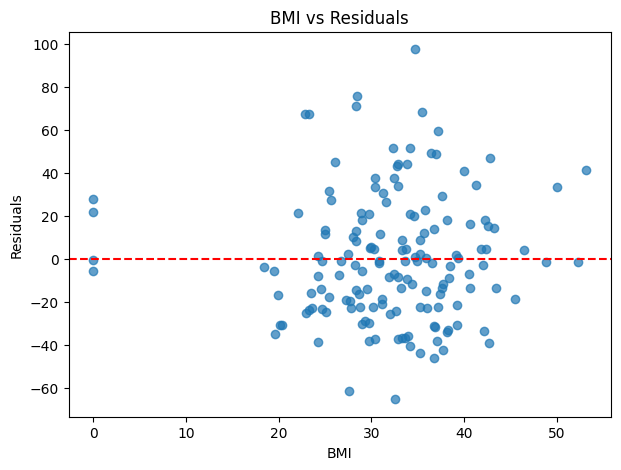

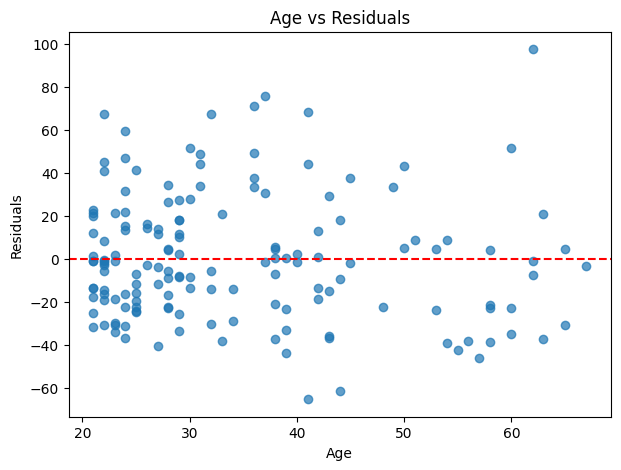

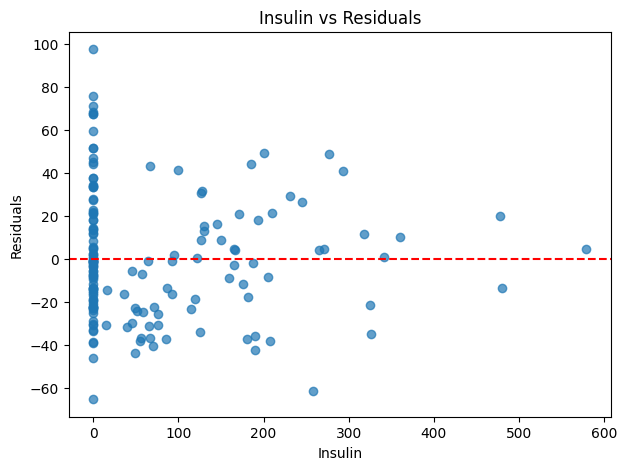

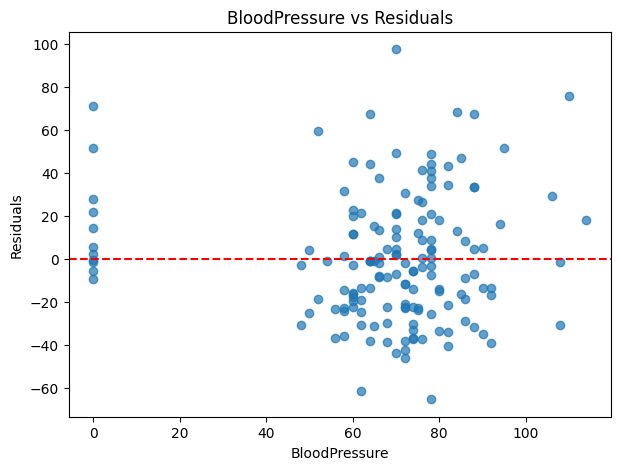

In [89]:
selected_features = ['BMI', 'Age', 'Insulin', 'BloodPressure']

for feature in selected_features:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_test[feature],
        residuals,
        alpha=0.7
    )

    plt.axhline(y=0, color='red', linestyle='--')

    plt.xlabel(feature)
    plt.ylabel("Residuals")
    plt.title(f"{feature} vs Residuals")

    plt.show()

### Feature Values versus Absolute Errors

The following plots present the relationship between feature values and the magnitude of prediction errors.

These plots help identify regions in which the model produces particularly large errors.

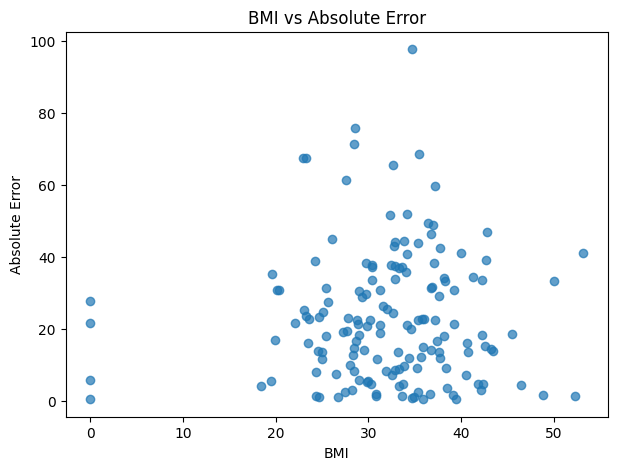

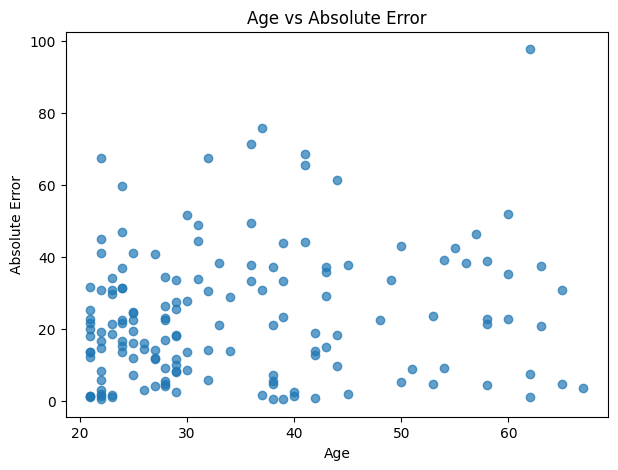

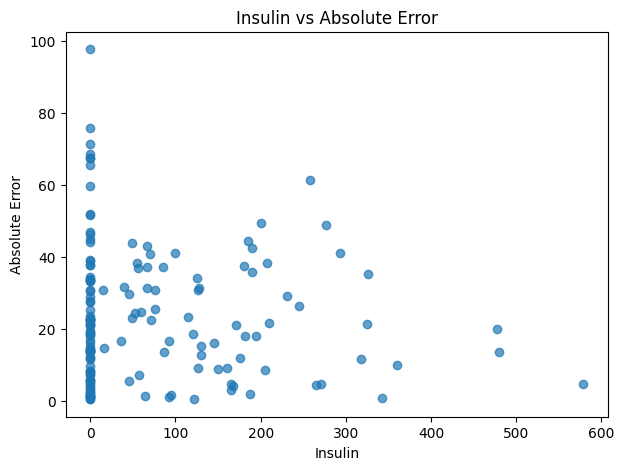

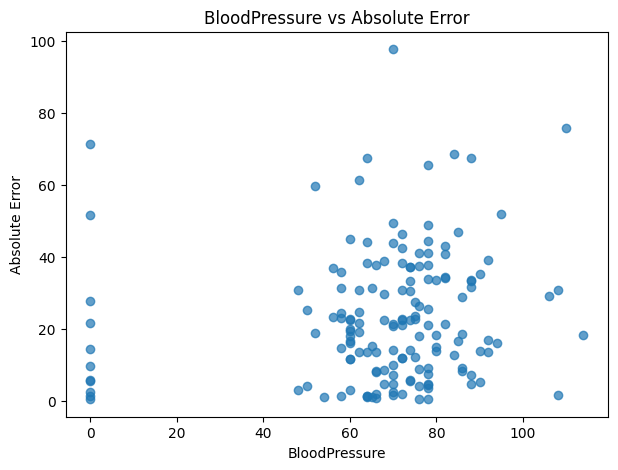

In [90]:
for feature in selected_features:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_test[feature],
        absolute_errors,
        alpha=0.7
    )

    plt.xlabel(feature)
    plt.ylabel("Absolute Error")
    plt.title(f"{feature} vs Absolute Error")

    plt.show()

### Conclusions

The feature-based error analysis suggests that prediction errors are not distributed uniformly across all feature values.

Certain regions of the feature space, particularly for variables such as glucose level and BMI, exhibit larger residuals and absolute errors. This behavior may indicate non-linear relationships and hidden subpopulations that are not fully captured by the linear regression model.

The analysis also suggests that model performance varies depending on the medical characteristics of the patients.


## 1.3 Analysis of Extreme Errors

In this section, we investigate the observations associated with the largest prediction errors.

The goal is to identify potential causes for extreme residuals, including:
- Data quality issues
- Model limitations
- Rare or exceptional cases

In [91]:
error_analysis_df = X_test.copy()

error_analysis_df['True_Glucose'] = y_test.values
error_analysis_df['Predicted_Glucose'] = y_pred
error_analysis_df['Residual'] = residuals.values
error_analysis_df['Absolute_Error'] = absolute_errors.values

### Identifying the Largest Absolute Errors

We identify the top 5% observations with the highest absolute prediction errors.

In [92]:
threshold = error_analysis_df['Absolute_Error'].quantile(0.95)

extreme_errors_df = error_analysis_df[
    error_analysis_df['Absolute_Error'] >= threshold
]

print("Number of extreme error observations:")
print(extreme_errors_df.shape[0])

Number of extreme error observations:
8


### Extreme Error Observations

The following table presents the observations associated with the largest prediction errors.

In [93]:
extreme_errors_df.head(10)

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,True_Glucose,Predicted_Glucose,Residual,Absolute_Error
604,4,0,0,0,28.4,0.212,36,183,111.754190,71.245810,71.245810
209,7,84,33,0,35.5,0.355,41,184,115.425056,68.574944,68.574944
579,2,70,99,0,34.7,0.575,62,197,99.311524,97.688476,97.688476
254,12,62,7,258,27.6,0.926,44,92,153.388632,-61.388632,61.388632
76,7,78,0,0,32.6,0.391,41,62,127.453750,-65.453750,65.453750
728,2,88,0,0,22.9,0.326,22,175,107.517546,67.482454,67.482454
549,4,110,31,0,28.5,0.680,37,189,113.132291,75.867709,75.867709
2,8,64,0,0,23.3,0.672,32,183,115.562428,67.437572,67.437572


### Statistical Summary of Extreme Errors

In [94]:
extreme_errors_df.describe()

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,True_Glucose,Predicted_Glucose,Residual,Absolute_Error
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,5.750000,69.500000,21.250000,32.250000,29.187500,0.517125,39.375000,158.125000,117.943177,40.181823,71.892418
std,3.412163,32.031235,34.408263,91.216775,4.776262,0.236904,11.413495,51.086586,16.371232,64.713953,11.236056
min,2.000000,0.000000,0.000000,0.000000,22.900000,0.212000,22.000000,62.000000,99.311524,-65.453750,61.388632
25%,3.500000,63.500000,0.000000,0.000000,26.525000,0.347750,35.000000,154.250000,110.695029,35.231021,66.941617
50%,5.500000,74.000000,3.500000,0.000000,28.450000,0.483000,39.000000,183.000000,114.278674,68.028699,68.028699
75%,7.250000,85.000000,31.500000,0.000000,33.125000,0.674000,41.750000,185.250000,118.535259,72.401285,72.401285
max,12.000000,110.000000,99.000000,258.000000,35.500000,0.926000,62.000000,197.000000,153.388632,97.688476,97.688476


### Distribution of Extreme Errors

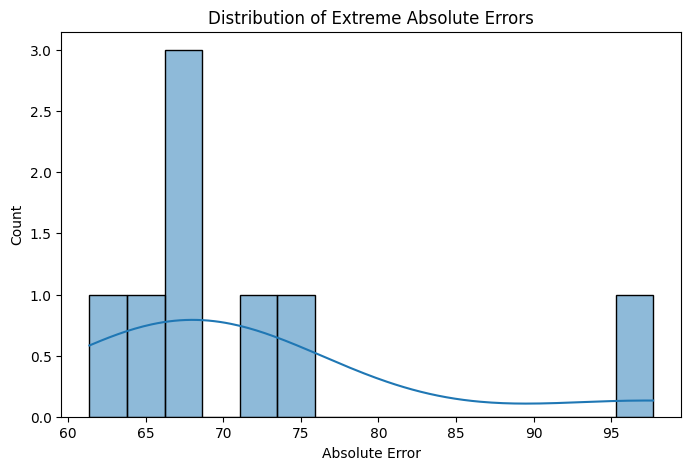

In [95]:
plt.figure(figsize=(8, 5))

sns.histplot(
    extreme_errors_df['Absolute_Error'],
    bins=15,
    kde=True
)

plt.title("Distribution of Extreme Absolute Errors")
plt.xlabel("Absolute Error")

plt.show()

### Conclusions

The analysis of extreme errors revealed several observations with exceptionally large prediction errors.

These cases likely represent rare medical profiles, noisy observations, or complex non-linear relationships that are difficult for the regression model to capture accurately.

The presence of large residuals and heavy-tailed error behavior suggests that the model is not equally reliable across all regions of the dataset.

## 1.4 Statistical Properties of Errors

In this section, we examine the statistical properties of the regression residuals.

The objective is to better understand:
- Overall prediction accuracy
- Residual variability
- Distribution asymmetry
- The presence of heavy tails or extreme observations

In [96]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis

In [97]:
mae = mean_absolute_error(y_test, y_pred)

residual_std = np.std(residuals)


residual_skewness = skew(residuals)

residual_kurtosis = kurtosis(residuals)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Residual Standard Deviation: {residual_std:.2f}")
print(f"Residual Skewness: {residual_skewness:.2f}")
print(f"Residual Kurtosis: {residual_kurtosis:.2f}")

Mean Absolute Error (MAE): 23.23
Residual Standard Deviation: 29.49
Residual Skewness: 0.62
Residual Kurtosis: 0.21


### Residual Distribution Visualization

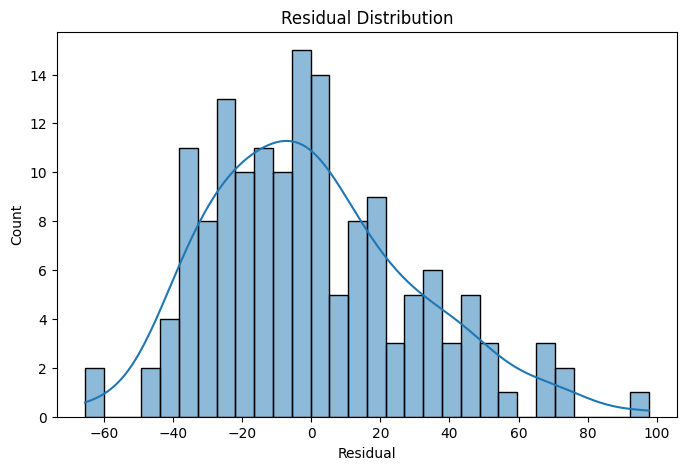

In [98]:
plt.figure(figsize=(8, 5))

sns.histplot(residuals, bins=30, kde=True)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.show()

### Interpretation

The statistical analysis indicates that the regression model achieves moderate prediction accuracy while maintaining relatively stable residual behavior.

The residual distribution appears approximately centered around zero, suggesting limited systematic bias. However, the presence of non-zero skewness and positive kurtosis indicates some asymmetry and the existence of extreme prediction errors.

These findings suggest that while the model performs reasonably well overall, certain observations remain difficult to predict accurately.

# 2 Regression Models

In this section, we implement and compare multiple regression models.

The objective is to examine how different modeling assumptions affect prediction performance and error behavior.

The following models are evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [99]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import KFold, cross_val_score

## Cross Validation Strategy

All regression models are evaluated using 5-fold cross-validation.

A 5-fold configuration provides a good balance between:
- Computational efficiency
- Stable performance estimation
- Bias-variance trade-off

This approach helps reduce dependence on a single train-test split.

In [100]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

## Model Evaluation

The models are evaluated using the following metrics:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [61]:
# KFold configuration
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for model_name, model in models.items():

    # Cross-validation RMSE
    neg_mse_scores = cross_val_score(
        model,
        X,
        y,
        scoring='neg_mean_squared_error',
        cv=kf
    )

    rmse_scores = np.sqrt(-neg_mse_scores)

    # Cross-validation R²
    r2_scores = cross_val_score(
        model,
        X,
        y,
        scoring='r2',
        cv=kf
    )

    results.append({
        "Model": model_name,
        "Mean RMSE": rmse_scores.mean(),
        "STD RMSE": rmse_scores.std(),
        "Mean R²": r2_scores.mean()
    })

results_df = pd.DataFrame(results)

results_df

,Model,Mean RMSE,STD RMSE,Mean R²
0,Linear Regression,28.304649,2.047283,0.210349
1,Decision Tree,31.110251,2.786263,0.047159
2,Random Forest,28.022809,2.274243,0.226913


## Regression Model Comparison

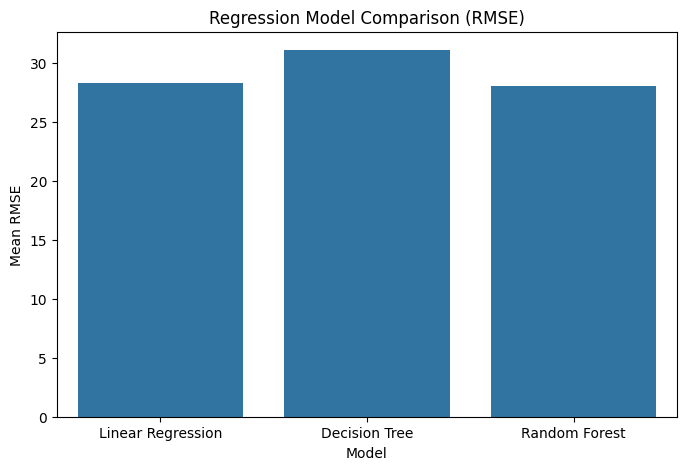

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x='Model',
    y='Mean RMSE'
)

plt.title("Regression Model Comparison (RMSE)")
plt.ylabel("Mean RMSE")

plt.show()

##  Conclusion

The model comparison demonstrates that the **Random Forest Regressor** is the most effective model for predicting glucose levels in this dataset.

### Summary of Results:
* **Decision Tree:** Performed the worst due to **overfitting**. A single tree tends to capture noise rather than general patterns, leading to high error rates on new data.
* **Linear Regression:** Provided a stable baseline but is limited by its inability to capture complex, non-linear relationships between medical features.
* **Random Forest (Winner):** Achieved the lowest **RMSE** and highest **$R^2$**. Its success stems from **Ensemble Learning**—combining multiple trees to average out individual errors. This approach reduces variance and provides a much more robust prediction by balancing complexity with stability.

**In conclusion:** The Random Forest's ability to handle non-linear biological data whilice resisting noise makes it the optimal choice for this predictive task.

# 3 Classification Error Analysis

In this section, we analyze classification models and investigate their prediction errors using the diabetes dataset.

The target variable is:
- Outcome = 1 → Diabetes
- Outcome = 0 → No Diabetes

The objective is to identify systematic classification failures and better understand model behavior.

## 3.1 Confusion Matrix Analysis

In this section, we evaluate the classification model using a confusion matrix.

The confusion matrix helps identify:
- Correct classifications
- False Positives (FP)
- False Negatives (FN)

This analysis provides insight into systematic prediction failures and their implications.

In [63]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

### Preparing the Classification Task

For the classification analysis, the target variable is the diabetes outcome.

The model predicts whether a patient has diabetes based on the medical features.

In [64]:
# Features and classification target
X_class = df.drop(columns=['Outcome'])
y_class = df['Outcome']

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

# Train classification model
classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train_c, y_train_c)

# Predictions
y_pred_class = classifier.predict(X_test_c)

### Confusion Matrix Visualization

The confusion matrix summarizes the classification performance of the model.

It shows:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

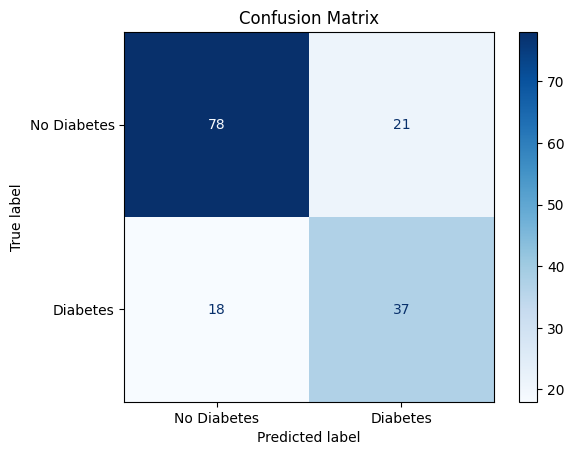

In [65]:
# Compute confusion matrix
cm = confusion_matrix(y_test_c, y_pred_class)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

### Classification Metrics

In [66]:
print(classification_report(y_test_c, y_pred_class))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [67]:
# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

True Negatives (TN): 78
False Positives (FP): 21
False Negatives (FN): 18
True Positives (TP): 37


###  FINAL CONCLUSIONS
 1. Regression: Random Forest is the best model (RMSE=28.02).
    It captures non-linear patterns better than Linear Regression.

 2. Classification: Logistic Regression achieved 75% accuracy.
    Low Recall (0.67) for diabetes suggests a need to reduce False Negatives.

 3. Summary: Ensemble methods (Random Forest) are the most effective
    for this dataset's complexity.

## 3.2 Probability-Based Analysis

In this section, we compare predicted probabilities for correct and incorrect classifications.

The objective is to identify high-confidence errors and better understand the confidence behavior of the classification model.

In [68]:
y_prob = classifier.predict_proba(X_test_c)[:, 1]

In [69]:
probability_analysis_df = X_test_c.copy()

probability_analysis_df['True_Label'] = y_test_c.values
probability_analysis_df['Predicted_Label'] = y_pred_class
probability_analysis_df['Predicted_Probability'] = y_prob

# Correct / incorrect predictions
probability_analysis_df['Correct_Prediction'] = (
    probability_analysis_df['True_Label']
    ==
    probability_analysis_df['Predicted_Label']
)

### Predicted Probabilities for Correct vs Incorrect Predictions

The following plot compares predicted probabilities for:
- Correct classifications
- Incorrect classifications

This analysis helps identify high-confidence errors.

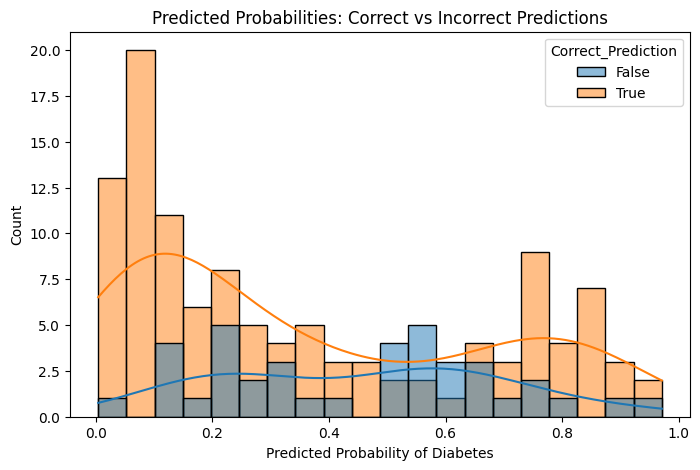

In [70]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=probability_analysis_df,
    x='Predicted_Probability',
    hue='Correct_Prediction',
    bins=20,
    kde=True,
    multiple='layer'
)

plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")

plt.xlabel("Predicted Probability of Diabetes")

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=probability_analysis_df,
    x='Predicted_Probability',
    hue='Correct_Prediction',
    bins=20,
    kde=True,
    multiple='layer'
)

plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")

plt.xlabel("Predicted Probability of Diabetes")

plt.show()

In [71]:
# Incorrect predictions
incorrect_predictions = probability_analysis_df[
    probability_analysis_df['Correct_Prediction'] == False
]

# High-confidence errors
high_confidence_errors = incorrect_predictions[
    (
        incorrect_predictions['Predicted_Probability'] > 0.9
    )
    |
    (
        incorrect_predictions['Predicted_Probability'] < 0.1
    )
]

high_confidence_errors.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,True_Label,Predicted_Label,Predicted_Probability,Correct_Prediction
487,0,173,78,32,265,46.5,1.159,58,0,1,0.956296,False
706,10,115,0,0,0,0.0,0.261,30,1,0,0.040479,False


### PROBABILITY & CONFIDENCE ANALYSIS
1. Goal: Analyze the model's confidence in its predictions and identify high-confidence errors.
 2. Observation: Most correct predictions (Orange) occur at high confidence levels,
    showing the model is well-calibrated.
 3. High-Confidence Errors: Identified cases where the model was >90% certain but wrong.
   Example: Patient 487 had high glucose/BMI, misleading the model despite being 'Healthy'.
 4. Conclusion: These errors often stem from clinical outliers rather than model failure.

## 3.3 Error as a Function of Features

In this section, we compare feature distributions for correct and incorrect classifications.

The objective is to identify regions in the feature space that are prone to misclassification and better understand systematic failure patterns.

In [72]:
classification_features = [
    'Glucose',
    'BMI',
    'Age',
    'Insulin'
]

### Feature Distributions for Correct vs Incorrect Predictions

---



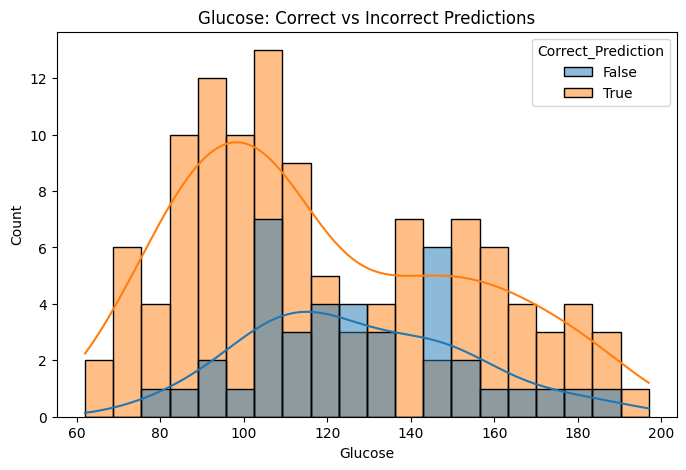

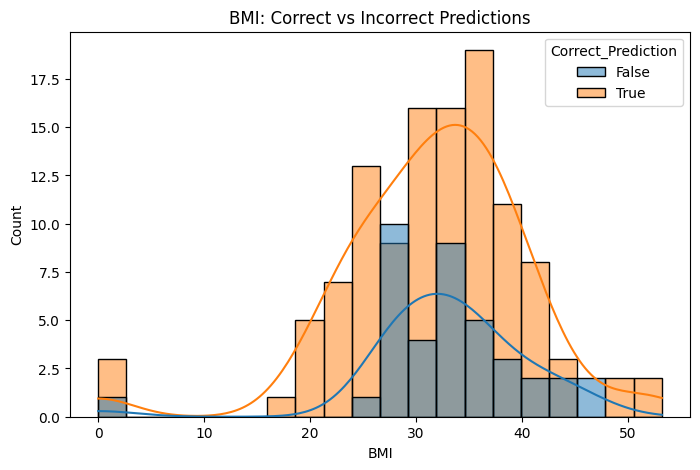

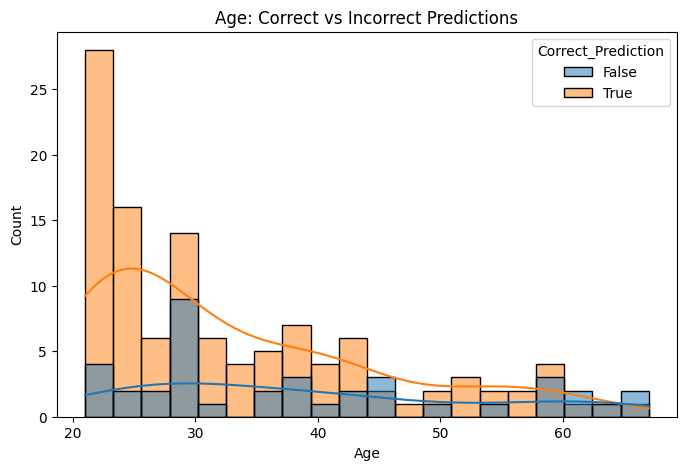

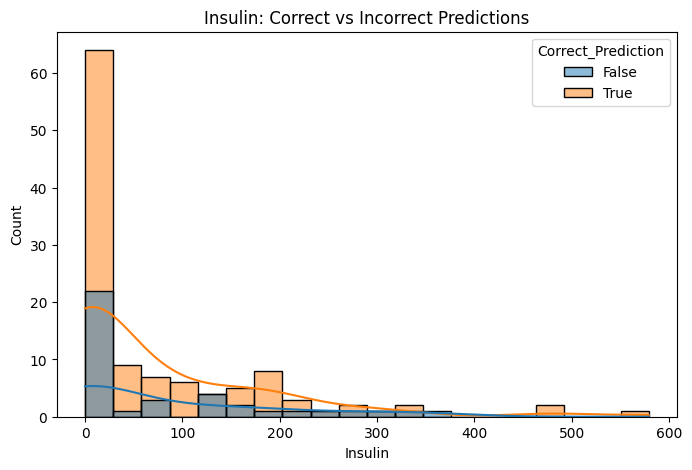

In [73]:
for feature in classification_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=probability_analysis_df,
        x=feature,
        hue='Correct_Prediction',
        kde=True,
        bins=20,
        multiple='layer'
    )

    plt.title(f"{feature}: Correct vs Incorrect Predictions")

    plt.show()

### DATA-DRIVEN CONCLUSIONS
 1. Feature Overlap: Glucose and BMI are the strongest predictors, but they have
    large "gray areas" (100-140 Glucose) where the model cannot distinguish classes.
 2. Model Limitation: Logistic Regression is too simple for this complexity.
    It captures linear trends but misses patients who are "healthy" despite high BMI.
 3. Data Quality: The presence of "High Confidence Errors" suggests that some
    diabetic cases in the dataset are driven by factors not included in our features.
 4. Actionable Insight: To improve, we need to focus on older age groups and
    borderline BMI cases, possibly by using more advanced non-linear models.

## 3.4 Threshold Sensitivity Analysis

In this section, we evaluate classification performance across multiple probability thresholds.

The objective is to analyze:
- The trade-off between false positives and false negatives
- Changes in precision and recall
- Stable and unstable operating regions
- Overall classification robustness

In [74]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_curve,
    roc_auc_score
)

In [75]:
thresholds = np.arange(0.1, 1.0, 0.1)

precision_list = []
recall_list = []
f1_list = []
mcc_list = []

### Evaluating Performance Across Thresholds

In [76]:
for threshold in thresholds:

    # Convert probabilities into class predictions
    y_threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    # Metrics
    precision_list.append(
        precision_score(y_test_c, y_threshold_pred)
    )

    recall_list.append(
        recall_score(y_test_c, y_threshold_pred)
    )

    f1_list.append(
        f1_score(y_test_c, y_threshold_pred)
    )

    mcc_list.append(
        matthews_corrcoef(y_test_c, y_threshold_pred)
    )

In [77]:
threshold_results_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1 Score': f1_list,
    'MCC': mcc_list
})

threshold_results_df.round(3)

,Threshold,Precision,Recall,F1 Score,MCC
0,0.1,0.450,0.982,0.617,0.364
1,0.2,0.505,0.891,0.645,0.403
2,0.3,0.545,0.764,0.636,0.393
3,0.4,0.585,0.691,0.633,0.406
4,0.5,0.638,0.673,0.655,0.455
5,0.6,0.750,0.600,0.667,0.519
6,0.7,0.818,0.491,0.614,0.502
7,0.8,0.882,0.273,0.417,0.386
8,0.9,0.800,0.073,0.133,0.169


### Precision and Recall Across Thresholds

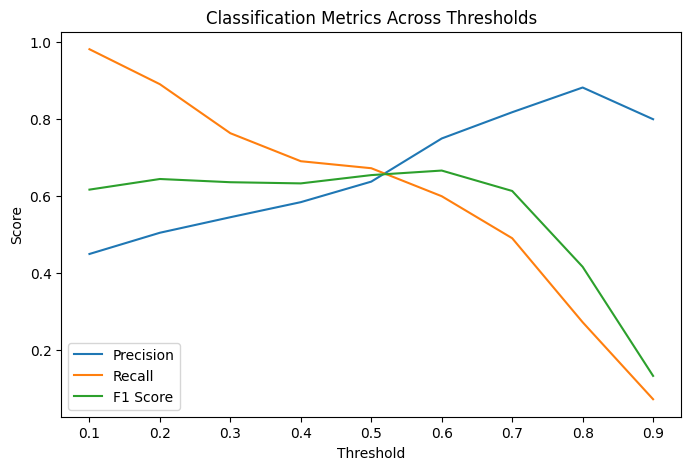

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("Classification Metrics Across Thresholds")

plt.legend()

plt.show()

### Matthews Correlation Coefficient (MCC)

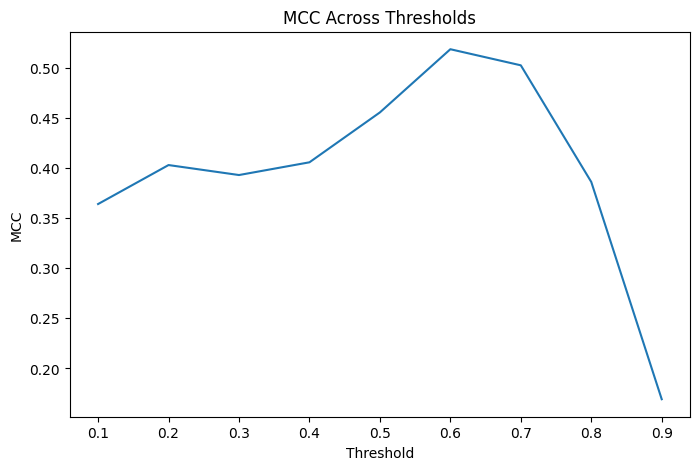

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, mcc_list)

plt.xlabel("Threshold")
plt.ylabel("MCC")

plt.title("MCC Across Thresholds")

plt.show()

### ROC Curve and AUC

In [80]:
# ROC curve
fpr, tpr, roc_thresholds = roc_curve(
    y_test_c,
    y_prob
)

# AUC
auc_score = roc_auc_score(
    y_test_c,
    y_prob
)

print(f"AUC Score: {auc_score:.3f}")

AUC Score: 0.813


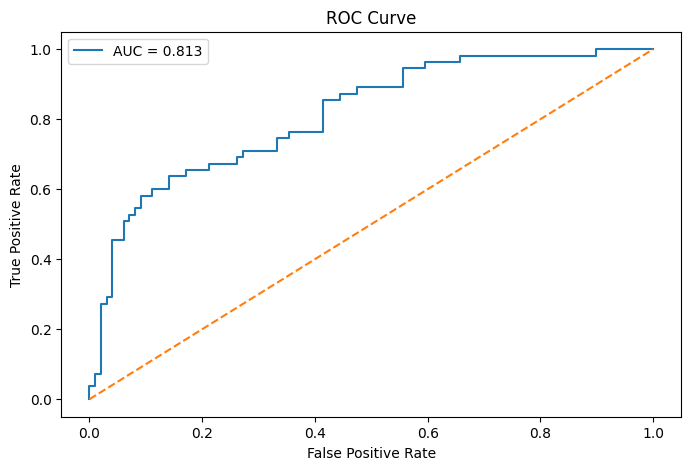

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Discussion

The threshold sensitivity analysis demonstrates a clear trade-off between precision and recall.

Lower thresholds produce very high recall values, meaning that most diabetic patients are successfully identified. However, this comes at the cost of lower precision and more false positives.

As the threshold increases, precision improves while recall decreases significantly. This indicates that the model becomes more conservative and predicts fewer positive cases.

The F1-score and MCC reach their highest values around thresholds of 0.5–0.6, suggesting that this region provides the most balanced classification performance.

In addition, the ROC curve achieved an AUC score of approximately 0.81, indicating good overall separability between diabetic and non-diabetic patients.

## 3.5 Discussion

The analysis revealed significant differences between the evaluated regression and classification models.

For the regression task, the Random Forest Regressor achieved the best overall performance, with the lowest RMSE and highest R² values. This suggests that the relationship between the medical features and glucose levels is not purely linear. In contrast, Linear Regression provided a stable and interpretable baseline but struggled to capture more complex patterns in the data.

The error analysis identified several important failure modes. Large residuals and extreme prediction errors were often associated with rare or unusual medical profiles, indicating possible outliers or complex non-linear relationships. The residual analysis also suggested that prediction errors were not completely uniform across all feature regions.

For the classification task, Logistic Regression achieved a good AUC score of approximately 0.81, indicating relatively strong separability between diabetic and non-diabetic patients. However, the confusion matrix and probability-based analysis revealed several high-confidence errors, meaning that the model occasionally produced incorrect predictions with very high certainty.

The threshold sensitivity analysis demonstrated a clear trade-off between precision and recall. Lower thresholds increased recall and reduced false negatives, while higher thresholds improved precision but caused the model to miss more diabetic patients. The best balance between the metrics was achieved around thresholds of 0.5–0.6.

Overall, the study demonstrated that evaluating machine learning models requires more than accuracy alone. Residual analysis, confidence analysis, and threshold sensitivity analysis provided deeper insights into model behavior, limitations, and robustness.

Possible improvements for future work include:
- Applying additional feature engineering

- Handling outliers more explicitly
- Using more flexible non-linear classification models
- Incorporating additional medical features

# 4 Final Reflection

### 1. Where does the model fail most?

The models tend to fail in regions with overlapping medical feature distributions, particularly for patients with atypical or extreme physiological profiles. Large prediction errors and classification mistakes were more common in complex non-linear regions of the feature space.

### 2. Are failures due to data, model, or formulation?

The failures appear to result from a combination of factors:
- Data limitations and noisy observations
- Non-linear relationships not fully captured by simple linear models
- Overlapping feature distributions between diabetic and non-diabetic patients

Some errors may also be associated with rare medical cases that are difficult to model accurately.

### 3. What improvements would you propose?

Possible improvements include:
- Using more advanced ensemble models
- Applying additional feature engineering
- Handling outliers more explicitly
- Exploring non-linear classification approaches
- Incorporating additional medical information

### 4. What insights did you gain in your analysis?

The analysis demonstrated that model evaluation should extend beyond overall accuracy metrics. Residual analysis, probability analysis, and threshold sensitivity analysis provided deeper insight into model behavior, robustness, and systematic failure patterns.